In [56]:
#imports
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chisquare

def df(file): 
    df = pd.read_csv(file)
    return df

In [57]:
#constants
distance_uncertainty = 0.2 #cm

field_names = ["Time (s)", " Geiger Counts (counts/sample)"]

runs = {
    "Distance_26.5cm": 26.5,
    "Distance_20.5cm": 20.5,
    "Distance_14.5cm": 14.5,
    "Distance_8.5cm": 8.5,
    "Distance_2.5cm": 2.5,
    "Distance_0cm": 0
}

noise_names = ["Background_Run1", "Background_Run2", "Background_Run3"]

histogram_data_names = [
    "Sampling_0_5Hz.csv",
    "Sampling_1Hz.csv",
    "Sampling_5Hz.csv",
    "Sampling_10Hz.csv",
    "Sampling_50Hz.csv",
    "Sampling_100Hz.csv",
]

In [58]:
noices = []
for name in noise_names:
    data = df(f"noise/{name}.csv")[field_names[1]].to_numpy()
    avg_data = np.mean(data)
    noices.append(avg_data)
    
noise = np.average(noices)

In [59]:
#equations

#Poisson distribution
def poisson(x, mew):
    eq = ((mew**x)* math.exp(-mew))/(math.gamma(x + 1))
    return eq

##gaussian distribution
def gausian(x, mew, sigma):
    eq = math.exp(-((x- mew)**2)/(2*(sigma**2)))/(math.sqrt(2*math.pi*(sigma**2)))
    return eq

In [60]:
#histogram
averages = {}
for key in runs:
    data = df(f"length_data/{key}.csv")[field_names[1]].to_numpy()
    avg_data = np.mean(data)
    averages[key] = avg_data - noise
    #plt.hist(data, bins=10, alpha=0.5, label=key)



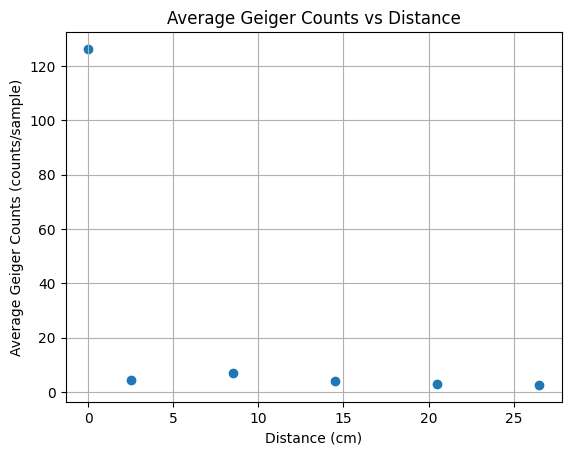

In [61]:
run_length = list(runs.values())
run_averages = list(averages.values())

plt.scatter(run_length, run_averages)
plt.xlabel("Distance (cm)")
plt.ylabel("Average Geiger Counts (counts/sample)")
plt.title("Average Geiger Counts vs Distance")
plt.grid()

Gaussian fit R^2: -0.070
Poisson fit R^2: -0.066
Chi-square Gaussian: stat=4.120, p=nan
Chi-square Poisson: stat=2.473, p=nan
Better fit: Poisson


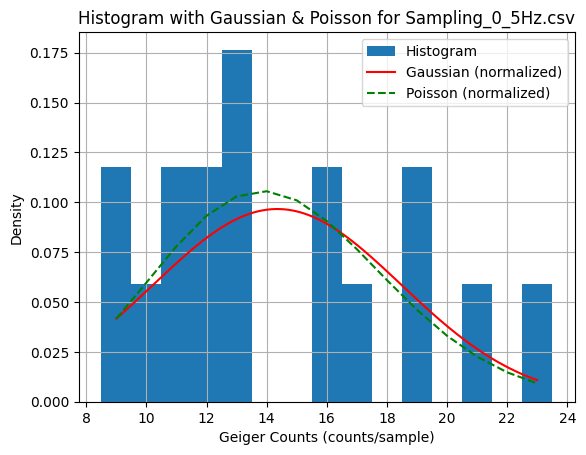

Gaussian fit R^2: 0.539
Poisson fit R^2: 0.634
Chi-square Gaussian: stat=3.086, p=0.214
Chi-square Poisson: stat=2.700, p=0.609
Better fit: Poisson


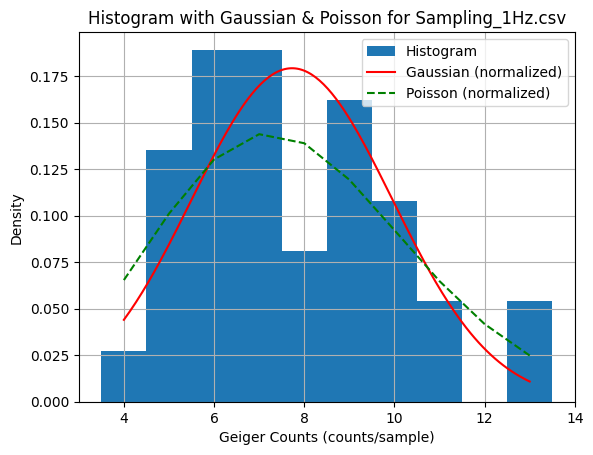

Gaussian fit R^2: 0.886
Poisson fit R^2: 0.988
Chi-square Gaussian: stat=4.106, p=0.043
Chi-square Poisson: stat=0.144, p=0.931
Better fit: Poisson


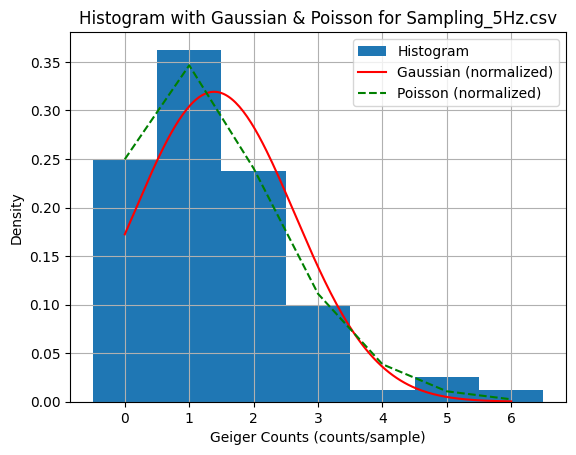

Gaussian fit R^2: 0.670
Poisson fit R^2: 0.998
Chi-square Gaussian: stat=12.986, p=nan
Chi-square Poisson: stat=0.512, p=0.774
Better fit: Poisson


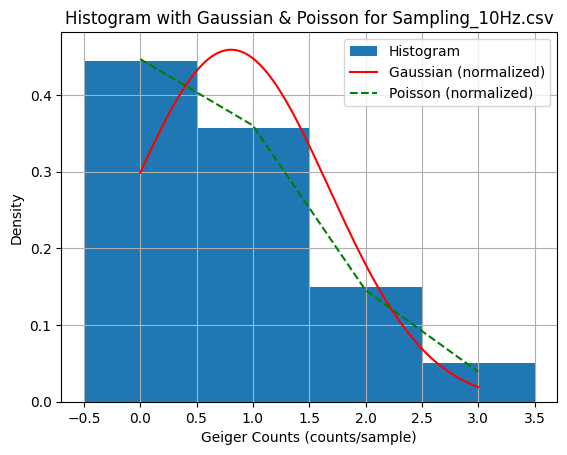

Gaussian fit R^2: 0.999
Poisson fit R^2: 1.000
Chi-square Gaussian: stat=3.148, p=nan
Chi-square Poisson: stat=0.482, p=0.487
Better fit: Poisson


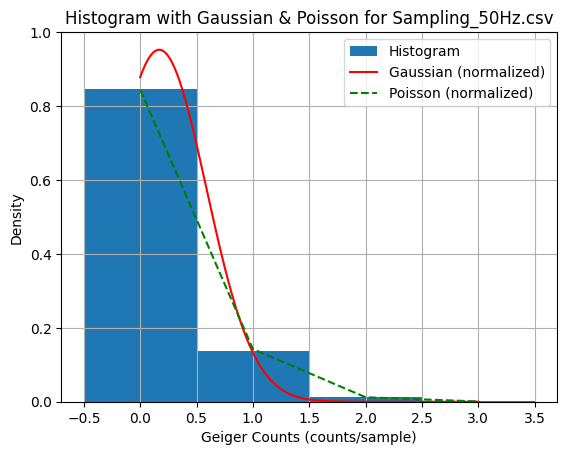

Gaussian fit R^2: 0.977
Poisson fit R^2: 1.000
Chi-square Gaussian: stat=1515.207, p=nan
Chi-square Poisson: stat=1.279, p=0.258
Better fit: Poisson


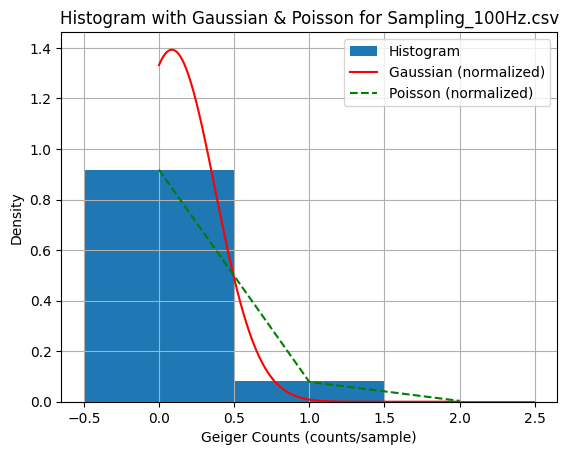

In [62]:
from scipy.stats import norm

for filename in histogram_data_names:
    data = df(f"sampling_tests/{filename}")[field_names[1]].to_numpy()
    plt.figure()
    
    mew = np.mean(data)
    sigma = np.std(data)
    
    # Use integer bins for discrete data
    x_min = int(np.min(data))
    x_max = int(np.max(data))
    bins = np.arange(x_min, x_max + 2) - 0.5  # center bins on integers
    
    plt.hist(data, bins=bins, alpha=1, density=True, label="Histogram")
    
    x = np.arange(x_min, x_max + 1)

    # Gaussian plot (smooth curve)
    x_smooth = np.linspace(x_min, x_max, 200)
    gauss_y_smooth = np.array([gausian(val, mew, sigma) for val in x_smooth])
    plt.plot(x_smooth, gauss_y_smooth, 'r-', label="Gaussian (normalized)")
    
    # Poisson plot
    pois_y = np.array([poisson(val, mew) for val in x])
    plt.plot(x, pois_y, 'g--', label="Poisson (normalized)")
    
    # Observed counts per integer value
    obs_counts = np.array([np.sum(data == val) for val in x])
    
    # Expected counts
    exp_gauss = np.array([gausian(val, mew, sigma) for val in x])
    exp_gauss = exp_gauss / exp_gauss.sum() * obs_counts.sum()
    
    exp_pois = np.array([poisson(val, mew) for val in x])
    exp_pois = exp_pois / exp_pois.sum() * obs_counts.sum()
    
    # Merge bins with expected < 5 (chi-square requirement)
    def merge_small_bins(obs, exp, min_exp=5):
        obs_m, exp_m = [], []
        o_acc, e_acc = 0, 0
        for o, e in zip(obs, exp):
            o_acc += o
            e_acc += e
            if e_acc >= min_exp:
                obs_m.append(o_acc)
                exp_m.append(e_acc)
                o_acc, e_acc = 0, 0
        if e_acc > 0:
            obs_m[-1] += o_acc
            exp_m[-1] += e_acc
        return np.array(obs_m), np.array(exp_m)
    
    obs_g, exp_g = merge_small_bins(obs_counts, exp_gauss)
    obs_p, exp_p = merge_small_bins(obs_counts, exp_pois)
    
    # R^2 values
    hist_vals = obs_counts / obs_counts.sum()
    gauss_fit_vals = exp_gauss / exp_gauss.sum()
    pois_fit_vals = exp_pois / exp_pois.sum()
    
    ss_tot = np.sum((hist_vals - np.mean(hist_vals)) ** 2)
    r2 = 1 - np.sum((hist_vals - gauss_fit_vals) ** 2) / ss_tot
    r2_pois = 1 - np.sum((hist_vals - pois_fit_vals) ** 2) / ss_tot
    print(f"Gaussian fit R^2: {r2:.3f}")
    print(f"Poisson fit R^2: {r2_pois:.3f}")
    
    # ddof: 1 for Poisson (estimated mu), 2 for Gaussian (estimated mu, sigma)
    chi_gaussian = chisquare(obs_g, f_exp=exp_g, ddof=2)
    chi_poisson = chisquare(obs_p, f_exp=exp_p, ddof=1)
    print(f"Chi-square Gaussian: stat={chi_gaussian.statistic:.3f}, p={chi_gaussian.pvalue:.3f}")
    print(f"Chi-square Poisson: stat={chi_poisson.statistic:.3f}, p={chi_poisson.pvalue:.3f}")
    print("Better fit:", "Poisson" if chi_poisson.statistic < chi_gaussian.statistic else "Gaussian")
    
    plt.title(f"Histogram with Gaussian & Poisson for {filename}")
    plt.xlabel("Geiger Counts (counts/sample)")
    plt.ylabel("Density")
    plt.grid()
    plt.legend()
    plt.show()


3.572706354023478%
Gaussian fit R^2: 0.342
Poisson fit R^2: 0.337
Chi-square Gaussian: stat=15359.868, p=0.000
Chi-square Poisson: stat=130063207.133, p=0.000
Merge small bins: OFF
Better fit: Gaussian


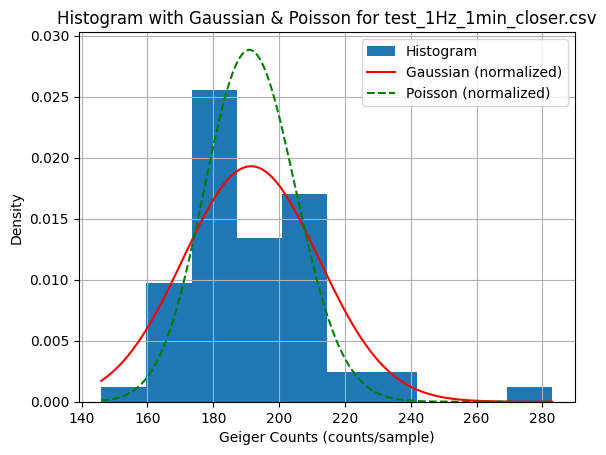

-1.6943478452577303%
Gaussian fit R^2: 0.897
Poisson fit R^2: 0.930
Chi-square Gaussian: stat=32.579, p=0.008
Chi-square Poisson: stat=15.777, p=0.540
Merge small bins: OFF
Better fit: Poisson


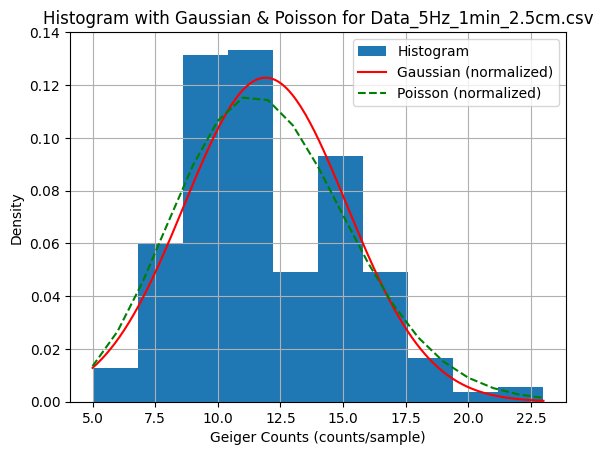

-1.4343233164861617%
Gaussian fit R^2: 0.894
Poisson fit R^2: 0.914
Chi-square Gaussian: stat=17.913, p=0.394
Chi-square Poisson: stat=13.030, p=0.790
Merge small bins: OFF
Better fit: Poisson


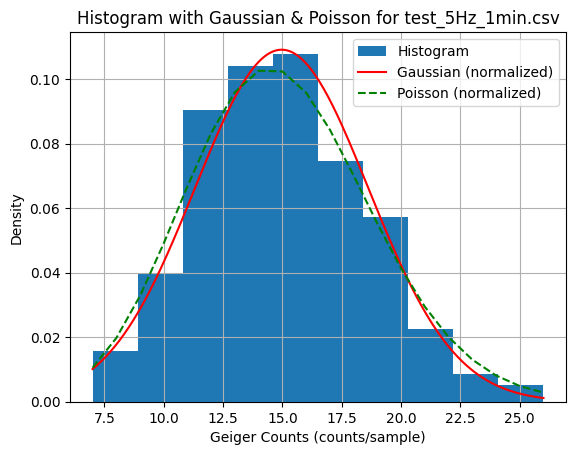

-2.0288046019973307%
Gaussian fit R^2: 0.977
Poisson fit R^2: 0.962
Chi-square Gaussian: stat=19.101, p=0.120
Chi-square Poisson: stat=13.601, p=0.480
Merge small bins: OFF
Better fit: Poisson


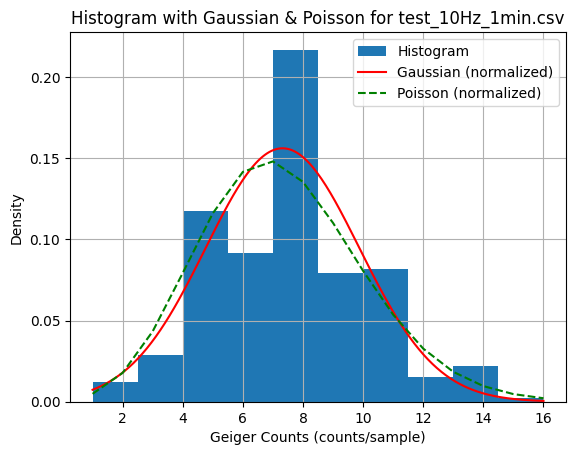

-2.4623994414923045%
Gaussian fit R^2: 0.969
Poisson fit R^2: 0.991
Chi-square Gaussian: stat=74.314, p=0.000
Chi-square Poisson: stat=9.009, p=0.436
Merge small bins: OFF
Better fit: Poisson


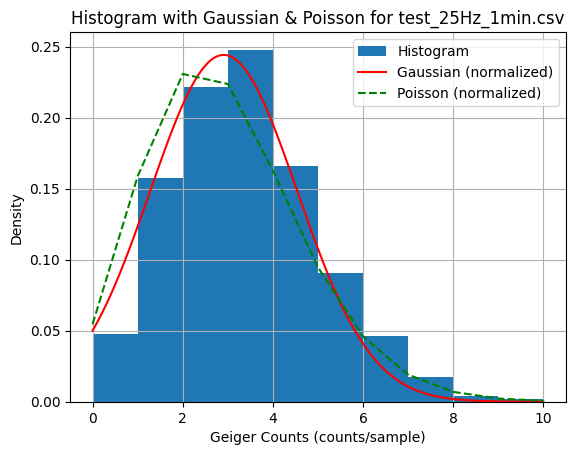

-1.1780073941289726%
Gaussian fit R^2: 0.959
Poisson fit R^2: 0.997
Chi-square Gaussian: stat=174.260, p=0.000
Chi-square Poisson: stat=5.508, p=0.598
Merge small bins: OFF
Better fit: Poisson


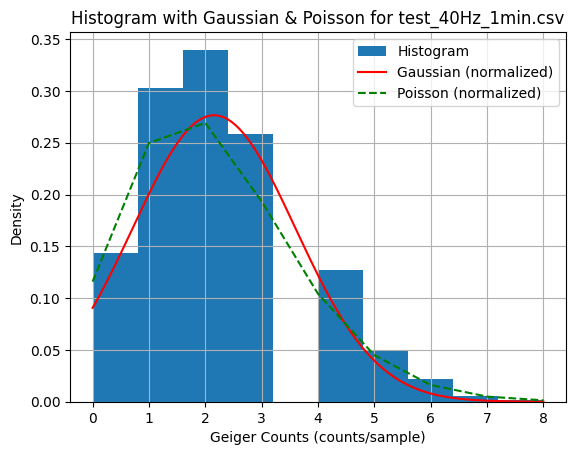

-2.28852238763849%
Gaussian fit R^2: 0.943
Poisson fit R^2: 0.996
Chi-square Gaussian: stat=282.758, p=0.000
Chi-square Poisson: stat=6.949, p=0.326
Merge small bins: OFF
Better fit: Poisson


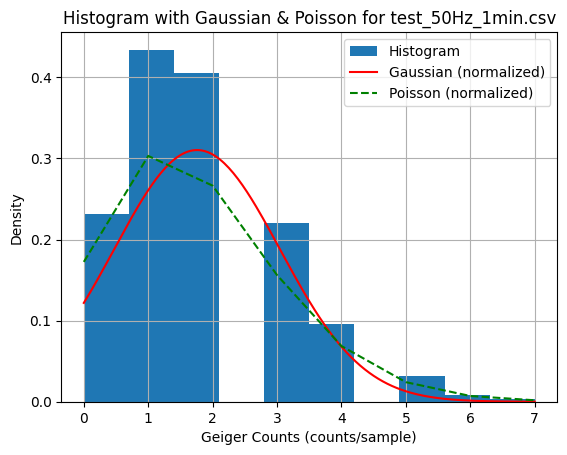

In [63]:
from scipy.special import gammaln

#some_more = ["Data_5Hz_1min_2.5cm.csv"]
some_more = ["test_1Hz_1min_closer.csv","Data_5Hz_1min_2.5cm.csv","test_5Hz_1min.csv","test_10Hz_1min.csv", "test_25Hz_1min.csv", "test_40Hz_1min.csv", "test_50Hz_1min.csv"] 

num_bins = 10  # Change this value to adjust the number of bins
merge_small = False  # Set to False to disable merging of small bins

for filename in some_more:
    data = df(f"data/{filename}")[field_names[1]].to_numpy()
    quarter_len = len(data)
    data = data[:quarter_len]
    plt.figure()
    
    mew = np.mean(data)
    sigma = np.std(data)
    
    difference = -np.sqrt(mew) + sigma
    difference_percent = (difference / mew) * 100
    print(f"{difference_percent}%")
    
    # Use integer bins for discrete data
    x_min = int(np.min(data))
    x_max = int(np.max(data))
    bins = np.arange(x_min, x_max + 2) - 0.5  # center bins on integers
    
    plt.hist(data, bins=num_bins, alpha=1, density=True, label="Histogram")
    
    x = np.arange(x_min, x_max + 1)

    # Gaussian plot
    x_smooth = np.linspace(x_min, x_max, 200)
    gauss_y_smooth = np.array([gausian(val, mew, sigma) for val in x_smooth])
    plt.plot(x_smooth, gauss_y_smooth, 'r-', label="Gaussian (normalized)")
    
    # Poisson plot - use log-space to avoid overflow with large values
    def poisson_safe(x, mu):
        return np.exp(x * np.log(mu) - mu - gammaln(x + 1))
    
    pois_y = np.array([poisson_safe(val, mew) for val in x])
    plt.plot(x, pois_y, 'g--', label="Poisson (normalized)")
    
    # Observed counts per integer value
    obs_counts = np.array([np.sum(data == val) for val in x])
    
    # Expected counts
    exp_gauss = np.array([gausian(val, mew, sigma) for val in x])
    exp_gauss = exp_gauss / exp_gauss.sum() * obs_counts.sum()
    
    exp_pois = np.array([poisson_safe(val, mew) for val in x])
    exp_pois = exp_pois / exp_pois.sum() * obs_counts.sum()
    
    # Merge bins with expected < 5 (chi-square requirement)
    def merge_small_bins(obs, exp, min_exp=5):
        obs_m, exp_m = [], []
        o_acc, e_acc = 0, 0
        for o, e in zip(obs, exp):
            o_acc += o
            e_acc += e
            if e_acc >= min_exp:
                obs_m.append(o_acc)
                exp_m.append(e_acc)
                o_acc, e_acc = 0, 0
        if e_acc > 0:
            obs_m[-1] += o_acc
            exp_m[-1] += e_acc
        return np.array(obs_m), np.array(exp_m)
    
    if merge_small:
        obs_g, exp_g = merge_small_bins(obs_counts, exp_gauss)
        obs_p, exp_p = merge_small_bins(obs_counts, exp_pois)
    else:
        obs_g, exp_g = obs_counts, exp_gauss
        obs_p, exp_p = obs_counts, exp_pois
    
    # R^2 values
    hist_vals = obs_counts / (obs_counts.sum())
    gauss_fit_vals = exp_gauss / exp_gauss.sum()
    pois_fit_vals = exp_pois / exp_pois.sum()
    
    ss_tot = np.sum((hist_vals - np.mean(hist_vals)) ** 2)
    r2 = 1 - np.sum((hist_vals - gauss_fit_vals) ** 2) / ss_tot
    r2_pois = 1 - np.sum((hist_vals - pois_fit_vals) ** 2) / ss_tot
    print(f"Gaussian fit R^2: {r2:.3f}")
    print(f"Poisson fit R^2: {r2_pois:.3f}")
    
    # ddof: 1 for Poisson (estimated mu), 2 for Gaussian (estimated mu, sigma)
    chi_gaussian = chisquare(obs_g, f_exp=exp_g, ddof=2)
    chi_poisson = chisquare(obs_p, f_exp=exp_p, ddof=1)
    print(f"Chi-square Gaussian: stat={chi_gaussian.statistic:.3f}, p={chi_gaussian.pvalue:.3f}")
    print(f"Chi-square Poisson: stat={chi_poisson.statistic:.3f}, p={chi_poisson.pvalue:.3f}")
    print(f"Merge small bins: {'ON' if merge_small else 'OFF'}")
    print("Better fit:", "Poisson" if chi_poisson.statistic < chi_gaussian.statistic else "Gaussian")
    
    plt.title(f"Histogram with Gaussian & Poisson for {filename}")
    plt.xlabel("Geiger Counts (counts/sample)")
    plt.ylabel("Density")
    plt.grid()
    plt.legend()
    plt.show()